## 🛠️ Setup & Imports

In [1]:
!nvidia-smi

Thu Apr 30 20:29:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   48C    P0            140W /  300W |    1751MiB /  46068MiB |     43%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%env CUDA_VISIBLE_DEVICES=1

env: CUDA_VISIBLE_DEVICES=1


In [1]:
import math
import os
import zipfile
import glob
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import xarray as xr
import pandas as pd
import torch
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torchinfo import summary

import sys
sys.path.append('../..')    # → consistency/  (pour flowmatching_models_FM)
sys.path.append('../../..')  # → 4dvarnet-starter-devs/  (pour src)

from flowmatching_models_FM import (
    UNetFM, UNetFMConfig,
    LitFlowMatchingModel, LitFMConfig,
    LogScaleModel,
    heun_sample, euler_sample,
    neglogpdf, neglogcdf,
    sample_uniform_time, masked_average,
)

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("⚠️  properscoring non installé — CRPS désactivé. Installer avec: pip install properscoring")

## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

In [3]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "/data/users/maxb/4dvarnet-starter-devs/SPDE/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset> Size: 79MB
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * lat        (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 20MB ...
    y          (time, lat, lon) float32 20MB ...
    OI         (time, lat, lon) float64 39MB ...
    H11        (lat, lon) float32 66kB ...
    H22        (lat, lon) float32 66kB ...
    H12        (lat, lon) float32 66kB ...
    Time       (time) int64 2kB ...
    longitude  (lon) int64 1kB ...
    latitude   (lat) int64 1kB ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('la

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)


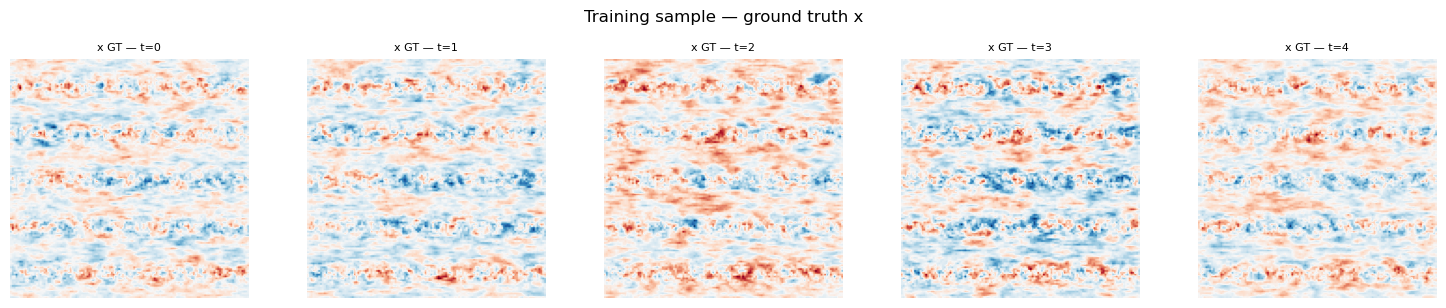

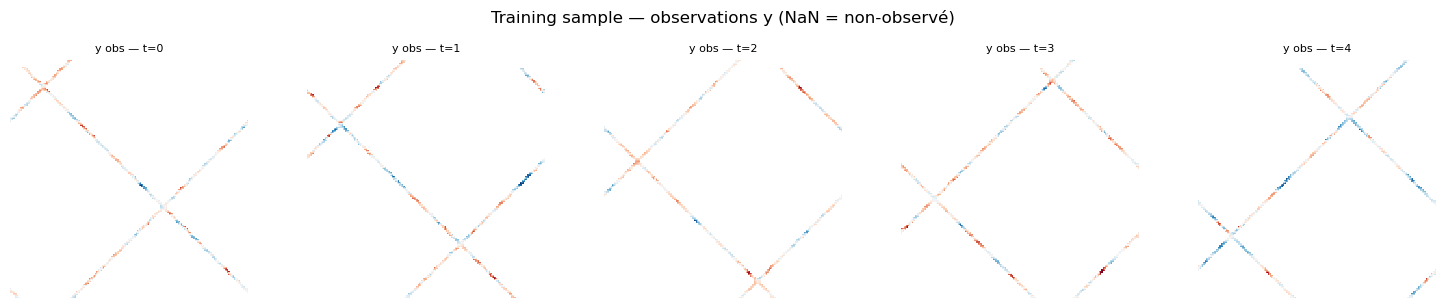

In [4]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = datamodule.window_size
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes — input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x GT — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — ground truth x", y=1.01)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y obs — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — observations y (NaN = non-observé)", y=1.01)
plt.tight_layout(); plt.show()

### UNetFM — Velocity-prediction network

Le réseau prend en entrée la concaténation `(x_t, y_filled, mask_obs)` → `3×C` canaux.  
Conditionné par **un seul** embedding de pseudo-temps `t ∈ [0,1]` (contrairement au CM qui utilise deux embeddings σ et σ').  
Prédit le **champ de vitesse** `v = x_1 - ε` de l'interpolant linéaire.

In [5]:
C = datamodule.window_size
cfg = UNetFMConfig(channels=C)
net = UNetFM(cfg)

summary(
    net,
    input_size=(
        (1, C, 100, 100),   # x_t  — noisy interpolant
        (1, C, 100, 100),   # y    — observations (NaN tolerated)
        (1,),               # t    — pseudo-time scalar
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNetFM                                        [1, 5, 100, 100]          --
├─Conv2d: 1-1                                 [1, 64, 104, 104]         8,704
├─TimeEmbedding: 1-2                          [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 64, 104, 104]         --
│    │    └─Sequential: 3-5                   [1, 64, 104, 104]         37,056
│    │    └─Sequential: 3-6                   [1, 64, 1, 1]             8,256
│ 

### LightningModule — LitFlowMatchingModel

Reprend l'interpolant linéaire de flow matching conditionnel :

$$x_t = t \cdot x_1 + (1-t) \cdot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,I)$$
$$v_\text{target} = x_1 - \varepsilon$$
$$\mathcal{L} = \mathbb{E}_{t,\varepsilon}\left[\text{NegLogPDF}\!\left(\frac{v_\text{target} - v_\theta(x_t, y, t)}{e^{s_\phi(t)}},\; s_\phi(t)\right)\right]$$

où $s_\phi(t)$ est le `LogScaleModel` (log-échelle apprise par variable).  
L'EMA du réseau est mise à jour après chaque batch (`swa_utils.AveragedModel`, decay=0.999).

In [6]:
# LitFlowMatchingModel is fully self-contained in flowmatching_models_FM.py.
# Inspect its docstring:
help(LitFlowMatchingModel)

Help on class LitFlowMatchingModel in module flowmatching_models_FM:

class LitFlowMatchingModel(pytorch_lightning.core.module.LightningModule)
 |  LitFlowMatchingModel(network: 'UNetFM', config: 'LitFMConfig', n_log_scale_embedding: 'int' = 128) -> 'None'
 |
 |  Flow Matching Lightning module for the SPDE dataset.
 |
 |  Parameters
 |  ----------
 |  network     : ``UNetFM`` (student / live model)
 |  config      : ``LitFMConfig``
 |  n_log_scale_embedding : embedding dim for the ``LogScaleModel``
 |
 |  Method resolution order:
 |      LitFlowMatchingModel
 |      pytorch_lightning.core.module.LightningModule
 |      lightning_fabric.utilities.device_dtype_mixin._DeviceDtypeModuleMixin
 |      pytorch_lightning.core.mixins.hparams_mixin.HyperparametersMixin
 |      pytorch_lightning.core.hooks.ModelHooks
 |      pytorch_lightning.core.hooks.DataHooks
 |      pytorch_lightning.core.hooks.CheckpointHooks
 |      torch.nn.modules.module.Module
 |      builtins.object
 |
 |  Methods defi

## 🚀 Training

In [ ]:
%tensorboard --logdir=logs_FM_spde --port 6008

In [7]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        import zipfile
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False


def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last) and is_valid_checkpoint(last):
        print(f"✅ Valid checkpoint: {last}")
        return last
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt")) if "last" not in p],
        key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", ""))
        if "train_loss=" in p else float("inf"),
    )
    for p in all_ckpts:
        if is_valid_checkpoint(p):
            print(f"✅ Valid checkpoint: {p}")
            return p
    print("❌ No valid checkpoint found. Starting from scratch.")
    return None


# ── Paths ──────────────────────────────────────────────────────────────────
C = datamodule.window_size

LOG_DIR     = "logs_FM_spde"
LOG_VERSION = "v1"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, LOG_VERSION, "best_model")

resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

# ── Model ──────────────────────────────────────────────────────────────────
network   = UNetFM(UNetFMConfig(channels=C))
lit_fm    = LitFlowMatchingModel(
    network=network,
    config=LitFMConfig(lr_scheduler_iters=1000, eval_n_steps=20),
)

# ── Trainer ────────────────────────────────────────────────────────────────
trainer = Trainer(
    accelerator="gpu",
    max_epochs=2500,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.fit(lit_fm, datamodule, ckpt_path=resume_ckpt)

# ── Save EMA model ─────────────────────────────────────────────────────────
ema_net = lit_fm.ema_model.module
ema_net.save_pretrained(MODEL_PATH)
print(f"✅ EMA model saved to: {MODEL_PATH}")

Using 16bit Automatic Mixed Precision (AMP)
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/dmidata/users/maxb/conda/en

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
✅ Val batch cached: tgt=torch.Size([1, 5, 128, 128])
✅ Val batch cached: tgt=torch.Size([1, 5, 128, 128])


/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 64 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

[Epoch 0]  Val RMSE (20 Heun steps, EMA) = 1.4411
[Epoch 1]  Val RMSE (20 Heun steps, EMA) = 1.4387
[Epoch 1]  Val RMSE (20 Heun steps, EMA) = 1.4387
[Epoch 2]  Val RMSE (20 Heun steps, EMA) = 1.4257
[Epoch 2]  Val RMSE (20 Heun steps, EMA) = 1.4257
[Epoch 3]  Val RMSE (20 Heun steps, EMA) = 1.4159
[Epoch 3]  Val RMSE (20 Heun steps, EMA) = 1.4159
[Epoch 4]  Val RMSE (20 Heun steps, EMA) = 1.4036
[Epoch 4]  Val RMSE (20 Heun steps, EMA) = 1.4036
[Epoch 5]  Val RMSE (20 Heun steps, EMA) = 1.3829
[Epoch 5]  Val RMSE (20 Heun steps, EMA) = 1.3829
[Epoch 6]  Val RMSE (20 Heun steps, EMA) = 1.3499
[Epoch 6]  Val RMSE (20 Heun steps, EMA) = 1.3499
[Epoch 7]  Val RMSE (20 Heun steps, EMA) = 1.3114
[Epoch 7]  Val RMSE (20 Heun steps, EMA) = 1.3114
[Epoch 8]  Val RMSE (20 Heun steps, EMA) = 1.2785
[Epoch 8]  Val RMSE (20 Heun steps, EMA) = 1.2785
[Epoch 9]  Val RMSE (20 Heun steps, EMA) = 1.2409
[Epoch 9]  Val RMSE (20 Heun steps, EMA) = 1.2409
[Epoch 10]  Val RMSE (20 Heun steps, EMA) = 1.2031

/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


✅ EMA model saved to: logs_FM_spde/v1/best_model


## 🎲 Sampling & Evaluation

In [10]:

# ── Load EMA model for inference ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

# Must match MODEL_PATH used in the training cell
LOG_DIR     = "logs_FM_spde"
LOG_VERSION = "v1"
MODEL_PATH  = os.path.join(LOG_DIR, LOG_VERSION, "best_model")

ema_unet = UNetFM.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"EMA UNetFM loaded from {MODEL_PATH}")
print(f"  Device : {next(ema_unet.parameters()).device}")
print(f"  Params : {sum(p.numel() for p in ema_unet.parameters()):,}")


EMA UNetFM loaded from logs_FM_spde/v1/best_model
  Device : cuda:0
  Params : 32,269,829


### Batch de test

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
Test batch  x_gt:(4, 5, 128, 128)  y_obs:(4, 5, 128, 128)
⚠️  No 'oi' field in batch — using nan-filled obs as OI proxy


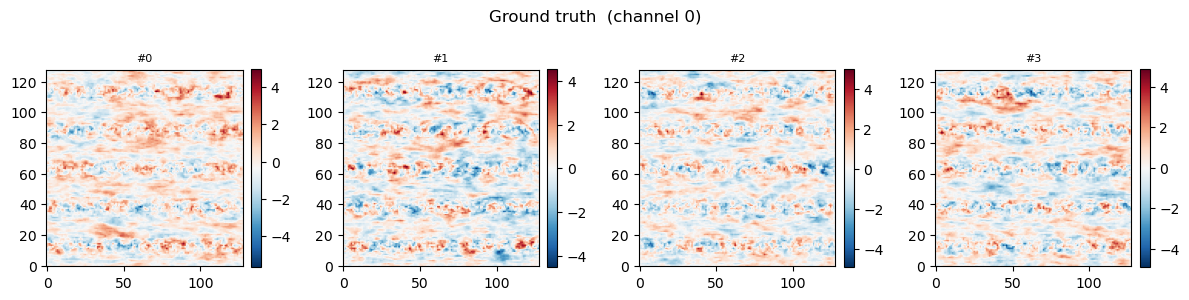

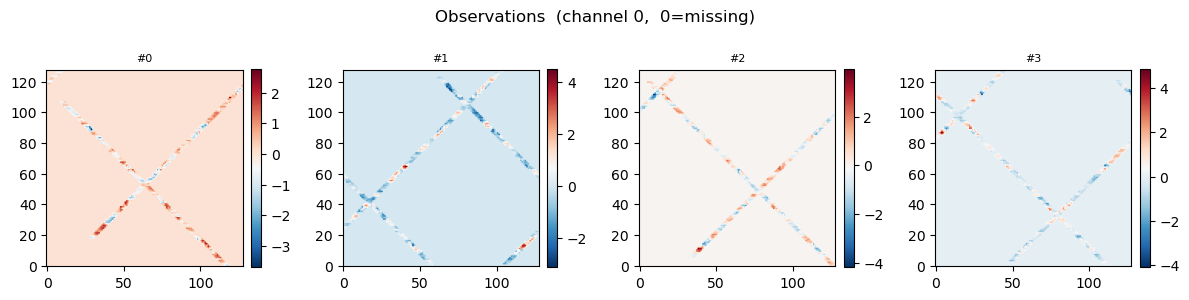

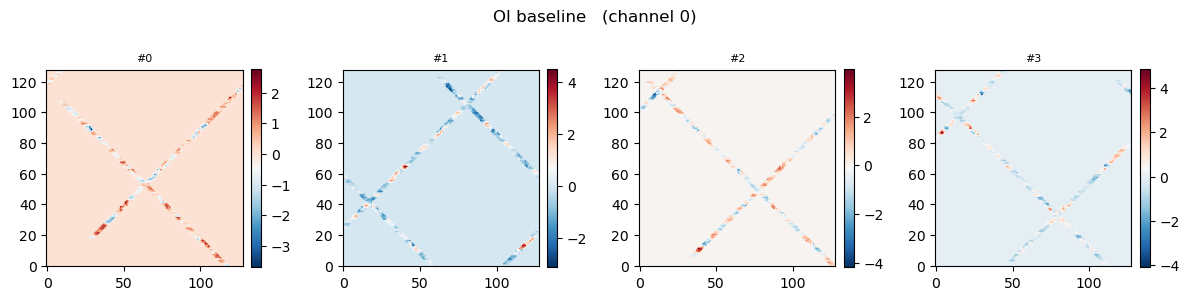

In [11]:

# ── Grab one test batch ───────────────────────────────────────────────────────
dm_test = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 4, "num_workers": 0},
)
dm_test.setup("test")
test_loader = dm_test.test_dataloader()

batch_test = next(iter(test_loader))
x_gt  = batch_test.tgt.to(device=device, dtype=dtype)    # (B, C, H, W)  ground truth
y_obs = batch_test.input.to(device=device, dtype=dtype)  # (B, C, H, W)  sparse obs (NaN=missing)

B, C, H, W = x_gt.shape
print(f"Test batch  x_gt:{tuple(x_gt.shape)}  y_obs:{tuple(y_obs.shape)}")

# OI baseline — use nan-filled obs as proxy if no 'oi' field
if hasattr(batch_test, "oi"):
    x_oi = batch_test.oi.to(device=device, dtype=dtype)
else:
    x_oi = torch.nan_to_num(y_obs, nan=0.0)
    print("⚠️  No 'oi' field in batch — using nan-filled obs as OI proxy")

# ── Plot helper ───────────────────────────────────────────────────────────────
def plot_field(arr: torch.Tensor, title: str = "", n_cols: int = 4, vmin=None, vmax=None):
    """arr: (N, H, W) or (H, W)"""
    arr = arr.detach().cpu().float()
    if arr.dim() == 2:
        arr = arr.unsqueeze(0)
    N = arr.shape[0]
    n_rows = (N + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < N:
            im = ax.imshow(arr[i], origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax)
            ax.set_title(f"#{i}", fontsize=8)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.axis("off")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# visualise GT and obs for the first channel
obs_vis = y_obs[:, 0].clone()
obs_vis[obs_vis.isnan()] = 0.0

plot_field(x_gt[:, 0], title="Ground truth  (channel 0)")
plot_field(obs_vis,     title="Observations  (channel 0,  0=missing)")
plot_field(x_oi[:, 0], title="OI baseline   (channel 0)")


### Génération d'ensemble  (N_SAMPLES membres)

Flow Matching est un modèle **stochastique** : chaque membre est obtenu en partant d'un bruit gaussien indépendant $\varepsilon \sim \mathcal{N}(0,I)$ et en intégrant l'ODE de Heun du temps $t=0$ vers $t=1$.

In [13]:

N_SAMPLES = 3
N_STEPS   = 20   # Heun ODE steps

samples = []  # list of (B, C, H, W) tensors

with torch.no_grad():
    for s in range(N_SAMPLES):
        noise = torch.randn_like(x_gt)                         # fresh noise per member
        x_pred, _ = heun_sample(ema_unet, noise, y_obs, n_steps=N_STEPS)
        samples.append(x_pred.cpu())
        if (s + 1) % 10 == 0:
            print(f"  member {s+1}/{N_SAMPLES} done")

samples = torch.stack(samples, dim=0)   # (N_SAMPLES, B, C, H, W)
print(f"Ensemble tensor: {tuple(samples.shape)}")

ens_mean = samples.mean(0)              # (B, C, H, W)
ens_std  = samples.std(0)              # (B, C, H, W)
print(f"Ensemble mean range: [{ens_mean.min():.3f}, {ens_mean.max():.3f}]")
print(f"Ensemble std  range: [{ens_std.min():.3f}, {ens_std.max():.3f}]")


Ensemble tensor: (3, 4, 5, 128, 128)
Ensemble mean range: [-3.835, 4.412]
Ensemble std  range: [0.000, 2.136]


## 📊 Métriques — FlowMatching vs OI

| Métrique | Description |
|---|---|
| **RMSE** | Erreur quadratique moyenne (ensemble mean vs GT) |
| **MAE** | Erreur absolue moyenne |
| **Spread** | Écart-type moyen de l'ensemble |
| **Spread/RMSE** | Ratio idéal = 1 |
| **CRPS** | Continuous Ranked Probability Score |

In [14]:

import pandas as pd

# ── Helper functions ──────────────────────────────────────────────────────────
def rmse(pred, gt):
    return (pred - gt).pow(2).mean().sqrt().item()

def mae(pred, gt):
    return (pred - gt).abs().mean().item()

def crps_ensemble(ens: torch.Tensor, gt: torch.Tensor) -> float:
    """
    Approximate CRPS via the energy-score decomposition:
      CRPS = E|X - y| - 0.5 * E|X - X'|
    ens : (N, *) ensemble members
    gt  : (*)    ground truth
    """
    N = ens.shape[0]
    mae_term = (ens - gt.unsqueeze(0)).abs().mean().item()
    # pair-wise spread  (unbiased estimator)
    spread_term = 0.0
    for i in range(N):
        spread_term += (ens[i] - ens[(i + 1) % N]).abs().mean().item()
    spread_term /= N
    return mae_term - 0.5 * spread_term

# ── Compute metrics ───────────────────────────────────────────────────────────
gt_cpu   = x_gt.cpu()
oi_cpu   = x_oi.cpu()
mean_cpu = ens_mean
std_cpu  = ens_std

rmse_fm  = rmse(mean_cpu, gt_cpu)
rmse_oi  = rmse(oi_cpu,   gt_cpu)
mae_fm   = mae(mean_cpu,  gt_cpu)
mae_oi   = mae(oi_cpu,    gt_cpu)
spread   = std_cpu.mean().item()
crps_fm  = crps_ensemble(samples[:, :, :, :, :], gt_cpu)   # (N,B,C,H,W) vs (B,C,H,W)

metrics = {
    "Model":        ["FM (ens. mean)", "OI baseline"],
    "RMSE":         [rmse_fm,  rmse_oi],
    "MAE":          [mae_fm,   mae_oi],
    "Spread":       [spread,   float("nan")],
    "Spread/RMSE":  [spread / rmse_fm, float("nan")],
    "CRPS":         [crps_fm, float("nan")],
}

df = pd.DataFrame(metrics).set_index("Model")
print(df.round(4).to_string())
df


                  RMSE     MAE  Spread  Spread/RMSE    CRPS
Model                                                      
FM (ens. mean)  0.9927  0.7566  0.2704       0.2724  0.6139
OI baseline     0.9702  0.7320     NaN          NaN     NaN


,RMSE,MAE,Spread,Spread/RMSE,CRPS
Model,,,,,
FM (ens. mean),0.992677,0.756562,0.270392,0.272387,0.613876
OI baseline,0.970174,0.732007,NaN,NaN,NaN


### PSD radiale

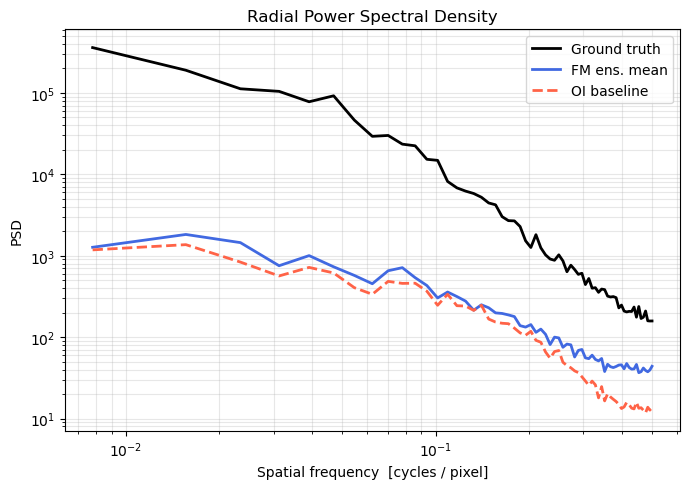

In [15]:

def compute_radial_psd(field: torch.Tensor) -> tuple:
    """
    Compute the azimuthally-averaged power spectral density.
    field : (B, C, H, W)  or  (N, B, C, H, W) → averaged over all leading dims
    Returns (freqs, psd) both 1-D numpy arrays.
    """
    f = field.float().cpu()
    # collapse batch / ensemble dims
    while f.dim() > 2:
        f = f.mean(0)
    H, W = f.shape

    F = torch.fft.fftshift(torch.fft.fft2(f))
    psd2d = F.abs().pow(2)

    cy, cx = H // 2, W // 2
    y_idx  = torch.arange(H).float() - cy
    x_idx  = torch.arange(W).float() - cx
    yy, xx = torch.meshgrid(y_idx, x_idx, indexing="ij")
    r      = (yy.pow(2) + xx.pow(2)).sqrt()

    max_r  = min(cy, cx)
    bins   = torch.arange(0, max_r + 1, dtype=torch.float32)
    psd1d  = torch.zeros(len(bins))
    counts = torch.zeros(len(bins))
    for i, b in enumerate(bins):
        mask = (r >= b - 0.5) & (r < b + 0.5)
        psd1d[i]  = psd2d[mask].mean()
        counts[i] = mask.float().sum()

    freqs = (bins / max(H, W)).numpy()
    return freqs, psd1d.numpy()

# ── Compute PSDs ──────────────────────────────────────────────────────────────
freqs_gt,   psd_gt   = compute_radial_psd(gt_cpu)
freqs_fm,   psd_fm   = compute_radial_psd(ens_mean)
freqs_oi,   psd_oi   = compute_radial_psd(oi_cpu)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(freqs_gt[1:], psd_gt[1:],  label="Ground truth", color="black",  lw=2)
ax.loglog(freqs_fm[1:], psd_fm[1:],  label="FM ens. mean", color="royalblue", lw=2)
ax.loglog(freqs_oi[1:], psd_oi[1:],  label="OI baseline",  color="tomato",   lw=2, ls="--")
ax.set_xlabel("Spatial frequency  [cycles / pixel]")
ax.set_ylabel("PSD")
ax.set_title("Radial Power Spectral Density")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


### Comparaison visuelle

`GT | obs | OI | FM mean | FM std | |FM-GT| | |OI-GT|`

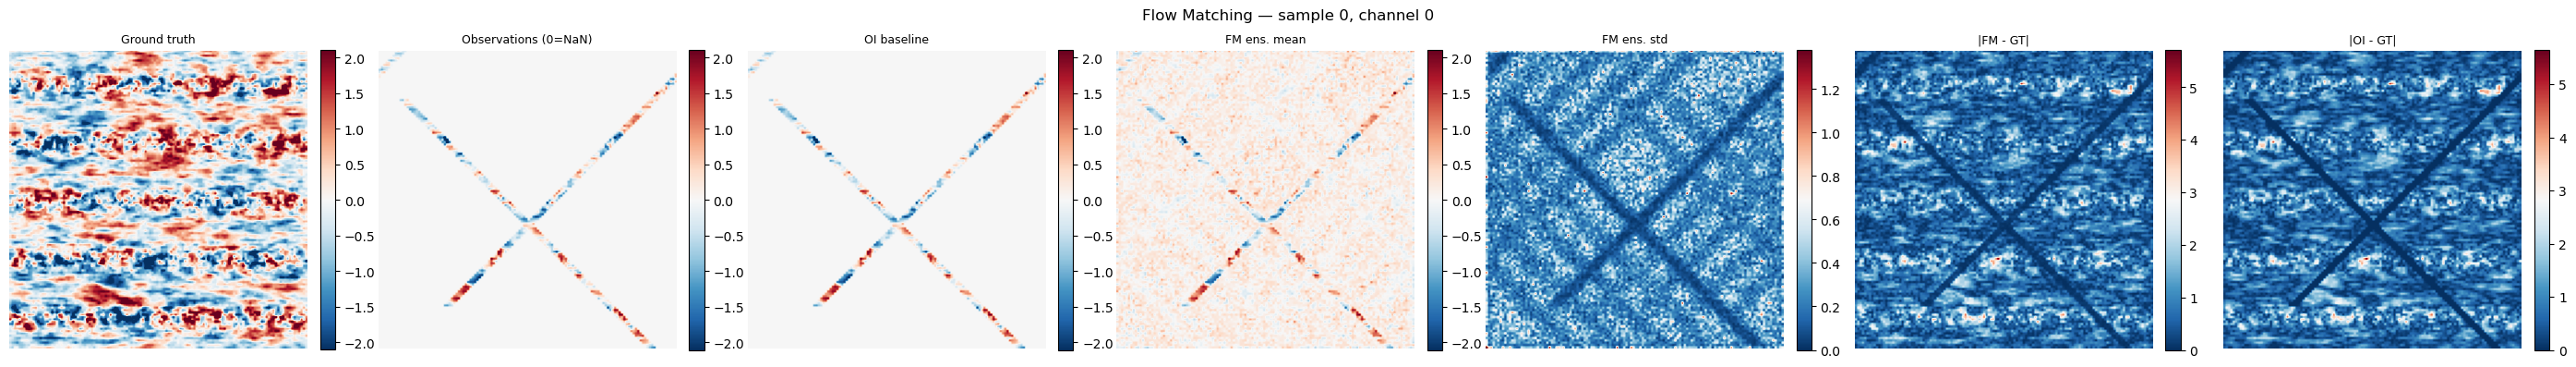

In [16]:

# Show one sample from the batch  (index IDX_B)
IDX_B = 0
IDX_C = 0   # channel

gt_s   = gt_cpu[IDX_B, IDX_C].numpy()
obs_s  = y_obs[IDX_B, IDX_C].cpu().numpy()
oi_s   = oi_cpu[IDX_B, IDX_C].numpy()
fm_m   = ens_mean[IDX_B, IDX_C].numpy()
fm_s   = ens_std[IDX_B, IDX_C].numpy()
err_fm = np.abs(fm_m - gt_s)
err_oi = np.abs(oi_s - gt_s)

obs_s_vis = np.where(np.isnan(obs_s), 0.0, obs_s)

vmin_f = float(np.nanpercentile(gt_s, 2))
vmax_f = float(np.nanpercentile(gt_s, 98))

panels = [
    (gt_s,      "Ground truth"),
    (obs_s_vis, "Observations (0=NaN)"),
    (oi_s,      "OI baseline"),
    (fm_m,      "FM ens. mean"),
    (fm_s,      "FM ens. std"),
    (err_fm,    "|FM - GT|"),
    (err_oi,    "|OI - GT|"),
]

fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
for ax, (arr, title) in zip(axes, panels):
    use_vmin = 0.0 if "std" in title or "|" in title else vmin_f
    use_vmax = None if "std" in title or "|" in title else vmax_f
    im = ax.imshow(arr, origin="lower", cmap="RdBu_r", vmin=use_vmin, vmax=use_vmax)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"Flow Matching — sample {IDX_B}, channel {IDX_C}", fontsize=12)
plt.tight_layout()
plt.show()


### Processus de débruitage — trajectoire ODE de Heun

Visualisation de la trajectoire ODE pour un membre : frames à $t=0, 0.1, \ldots, 1$.

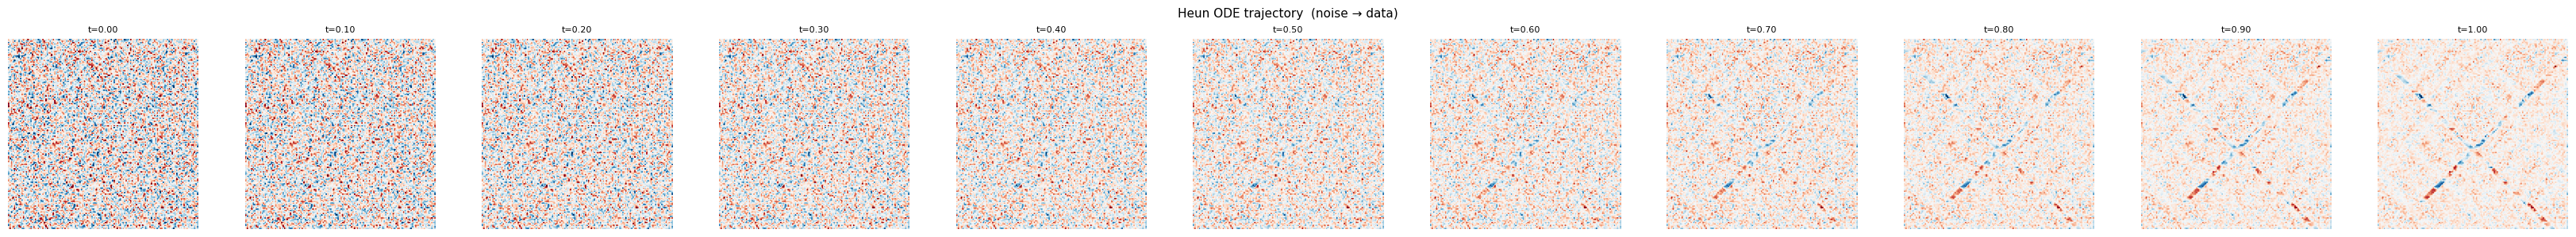

In [17]:

N_VIZ_STEPS = 10   # number of ODE steps for the trajectory
IDX_TRAJ    = 0    # which batch element

torch.manual_seed(42)
noise_traj = torch.randn(1, C, H, W, device=device, dtype=dtype)
y_traj     = y_obs[IDX_TRAJ : IDX_TRAJ + 1]

with torch.no_grad():
    _, trajectory = heun_sample(ema_unet, noise_traj, y_traj, n_steps=N_VIZ_STEPS)

# trajectory: list of (1, C, H, W) tensors, length = N_VIZ_STEPS + 1
n_frames = len(trajectory)
fig, axes = plt.subplots(1, n_frames, figsize=(3 * n_frames, 3))
for i, (frame, ax) in enumerate(zip(trajectory, axes)):
    t_val = i / (n_frames - 1)
    im = ax.imshow(frame[0, IDX_C].cpu().numpy(), origin="lower", cmap="RdBu_r",
                   vmin=vmin_f, vmax=vmax_f)
    ax.set_title(f"t={t_val:.2f}", fontsize=8)
    ax.axis("off")

plt.suptitle("Heun ODE trajectory  (noise → data)", fontsize=11)
plt.tight_layout()
plt.show()
